In [2]:
# ==============================================================================
# PART 1: FRAMEWORK INSTALLATIONS & ENVIRONMENT INITIALIZATION
# ==============================================================================
# Install the required Explainable AI modules
!pip install shap lime -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Engine Modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score, roc_curve

# Explainable AI Framework Modules
import shap
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings('ignore')

# Enable automatic plot rendering inside Colab UI
%matplotlib inline

print("✅ Part 1 Success: All industrial packages and XAI engines loaded with zero friction.")

✅ Part 1 Success: All industrial packages and XAI engines loaded with zero friction.


In [3]:
# ==============================================================================
# PART 2: DATASET LOADING
# ==============================================================================
try:
    df = pd.read_csv('bank.csv')
    print(f"✅ Part 2 Success: Loaded 'bank.csv' smoothly.")
    print(f"Data Shape: {df.shape[0]} Rows, {df.shape[1]} Columns.")
    print("\nInitial Data Structure Preview:")
    display(df.head(3))
except FileNotFoundError:
    print("❌ Error: 'bank.csv' not detected in working directory! Please upload it using the folder icon on the left sidebar.")

✅ Part 2 Success: Loaded 'bank.csv' smoothly.
Data Shape: 11162 Rows, 17 Columns.

Initial Data Structure Preview:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes


In [4]:
# ==============================================================================
# PART 3: DATA CLEANING AND PREPROCESSING
# ==============================================================================
# Explicit mapping of the string target variable 'deposit' to binary notation
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

# Segregate categorical elements for multi-layered encoding pipelines
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
df_encoded = df.copy()

# Instantiating independent LabelEncoder objects to eliminate feature overlap errors
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("✅ Part 3 Success: Mapped target arrays and encoded string arrays successfully.")

✅ Part 3 Success: Mapped target arrays and encoded string arrays successfully.


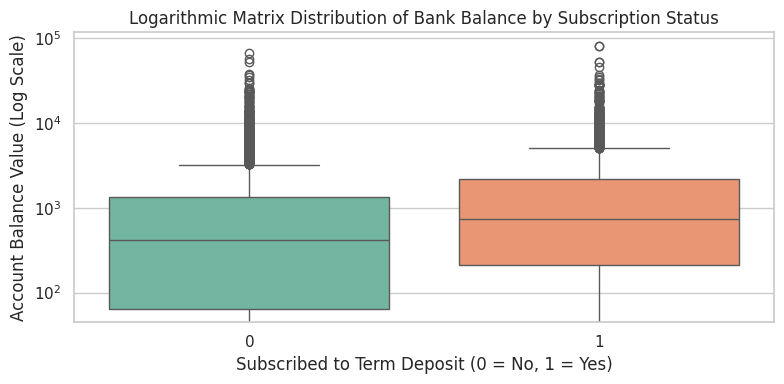

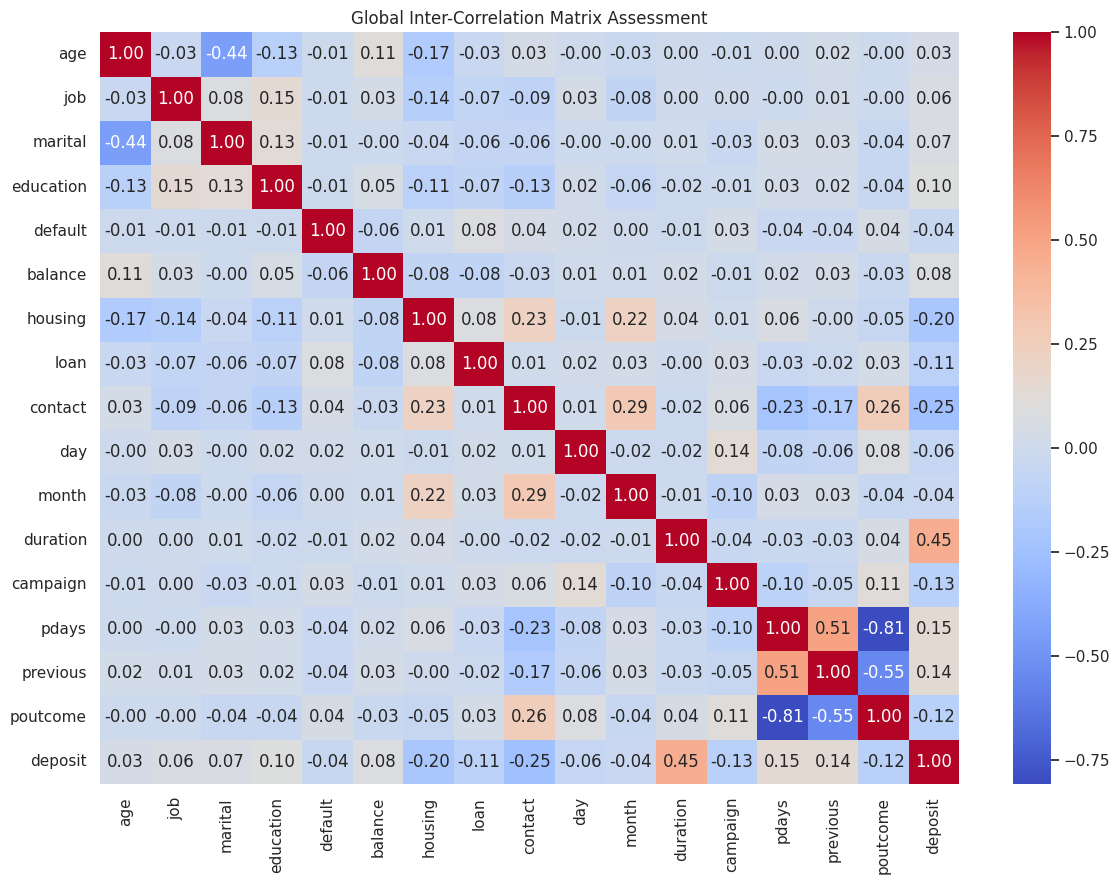

✅ Part 4 Success: EDA plots fully processed and saved down into workspace directory.


In [5]:
# ==============================================================================
# PART 4: EXPLORATORY DATA ANALYSIS (EDA) VISUALIZATIONS
# ==============================================================================
sns.set_theme(style="whitegrid")

# Visualization 1: Balance Stratification Across Target Variable Labels
plt.figure(figsize=(8, 4))
sns.boxplot(x='deposit', y='balance', data=df, palette='Set2')
plt.yscale('log')  # Apply log scale to gracefully handle extreme wealth outliers
plt.title('Logarithmic Matrix Distribution of Bank Balance by Subscription Status')
plt.xlabel('Subscribed to Term Deposit (0 = No, 1 = Yes)')
plt.ylabel('Account Balance Value (Log Scale)')
plt.tight_layout()
plt.savefig('balance_vs_deposit.png', dpi=300)
plt.show()

# Visualization 2: Feature Correlation Heatmap Matrix
plt.figure(figsize=(12, 9))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title('Global Inter-Correlation Matrix Assessment')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

print("✅ Part 4 Success: EDA plots fully processed and saved down into workspace directory.")


             METRICS REPORT: LOGISTIC REGRESSION BASELINE
Accuracy Score: 0.7971 | F1-Score: 0.7823
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      1175
           1       0.80      0.77      0.78      1058

    accuracy                           0.80      2233
   macro avg       0.80      0.80      0.80      2233
weighted avg       0.80      0.80      0.80      2233


             METRICS REPORT: RANDOM FOREST ENSEMBLE SYSTEM
Accuracy Score: 0.8477 | F1-Score: 0.8447
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1175
           1       0.82      0.87      0.84      1058

    accuracy                           0.85      2233
   macro avg       0.85      0.85      0.85      2233
weighted avg       0.85      0.85      0.85      2233



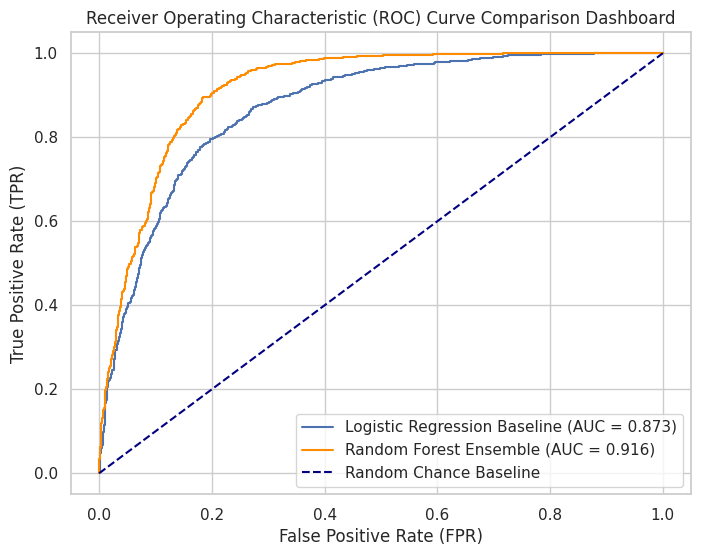

✅ Part 5 Success: Predictive algorithms evaluated successfully.


In [9]:
# ==============================================================================
# PART 5: MODEL TRAINING AND PREDICTIVE METRICS EVALUATION
# ==============================================================================
# Separating target space from the explanatory variables matrix
X = df_encoded.drop(columns=['deposit'])
y = df_encoded['deposit']

# Execute Stratified Split to cleanly balance classes across training/testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Feature Standardization Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Crucial Fix: Convert scaled numpy matrices back to clean DataFrames to retain feature column labels for XAI modules
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Model Architecture A: Standard Baseline Logistic Regression Classifier
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled_df, y_train)
y_pred_log = log_reg.predict(X_test_scaled_df)
y_prob_log = log_reg.predict_proba(X_test_scaled_df)[:, 1]

# Model Architecture B: Advanced Random Forest Ensemble Classifier
rf_clf = RandomForestClassifier(n_estimators=250, max_depth=15, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

# Evaluate and display performance comparison reports
print("\n" + "="*70)
print("             METRICS REPORT: LOGISTIC REGRESSION BASELINE")
print("="*70)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_log):.4f} | F1-Score: {f1_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log))

print("\n" + "="*70)
print("             METRICS REPORT: RANDOM FOREST ENSEMBLE SYSTEM")
print("="*70)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f} | F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

# Generate Multi-Model ROC Comparison Plot
plt.figure(figsize=(8, 6))
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression Baseline (AUC = {roc_auc_score(y_test, y_prob_log):.3f})')
plt.plot(fpr_rf, tpr_rf, color='darkorange', label=f'Random Forest Ensemble (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot([0, 1], color='navy', linestyle='--', label='Random Chance Baseline')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison Dashboard')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('roc_curve_comparison.png', dpi=300)
plt.show()

print("✅ Part 5 Success: Predictive algorithms evaluated successfully.")


--- Running Global Explainable AI Frameworks (SHAP) ---


<Figure size 1000x500 with 0 Axes>

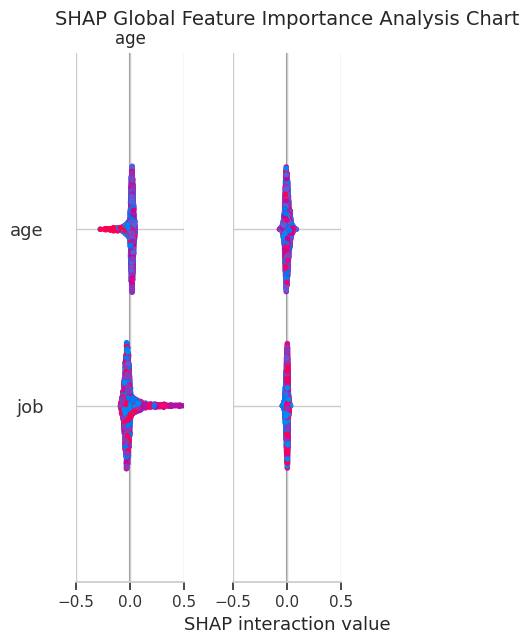

<Figure size 1000x500 with 0 Axes>

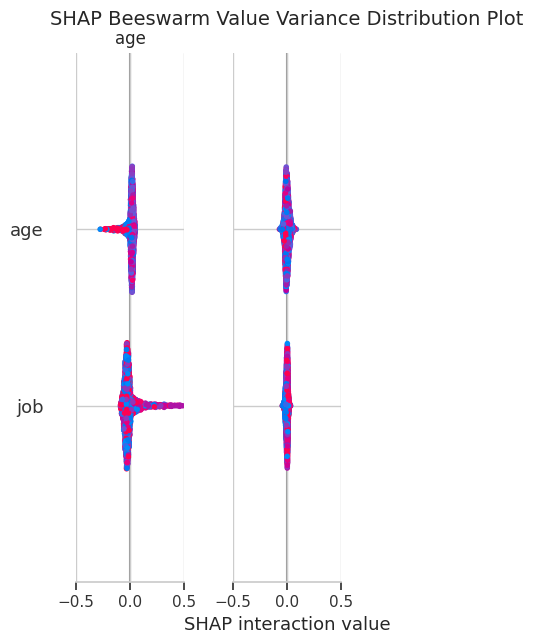


--- Running Local Explainer Framework (LIME) for 5 Distinct Predictions ---

 EXPLAINING CLIENT PROFILE RECORD 1/5 (Test Row Index: 0)
Ground Truth Real Label Class: 0
Model Predicted Probability Scores: [0.38393336 0.61606664]

Local Feature Weight Influence Summary:
   -> pdays <= -1.00                      : Local Coefficient Weight = -0.1182
   -> contact <= 0.00                     : Local Coefficient Weight = +0.0653
   -> previous <= 0.00                    : Local Coefficient Weight = -0.0618
   -> 253.00 < duration <= 492.00         : Local Coefficient Weight = +0.0516
   -> housing <= 0.00                     : Local Coefficient Weight = +0.0426


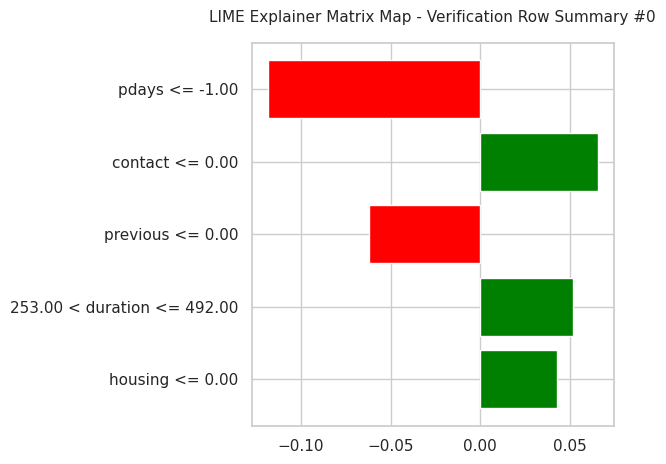


 EXPLAINING CLIENT PROFILE RECORD 2/5 (Test Row Index: 15)
Ground Truth Real Label Class: 0
Model Predicted Probability Scores: [0.86020773 0.13979227]

Local Feature Weight Influence Summary:
   -> pdays <= -1.00                      : Local Coefficient Weight = -0.1180
   -> contact > 1.00                      : Local Coefficient Weight = -0.0861
   -> previous <= 0.00                    : Local Coefficient Weight = -0.0566
   -> 0.00 < housing <= 1.00              : Local Coefficient Weight = -0.0537
   -> 253.00 < duration <= 492.00         : Local Coefficient Weight = +0.0507


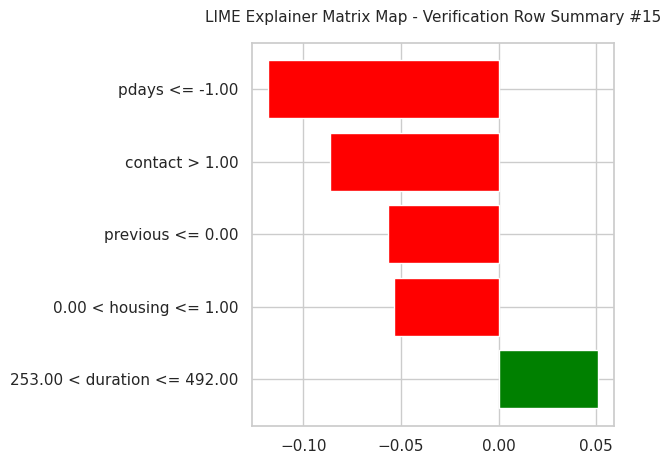


 EXPLAINING CLIENT PROFILE RECORD 3/5 (Test Row Index: 30)
Ground Truth Real Label Class: 0
Model Predicted Probability Scores: [0.96898596 0.03101404]

Local Feature Weight Influence Summary:
   -> duration <= 137.00                  : Local Coefficient Weight = -0.3403
   -> pdays <= -1.00                      : Local Coefficient Weight = -0.1117
   -> contact <= 0.00                     : Local Coefficient Weight = +0.0660
   -> previous <= 0.00                    : Local Coefficient Weight = -0.0622
   -> housing <= 0.00                     : Local Coefficient Weight = +0.0517


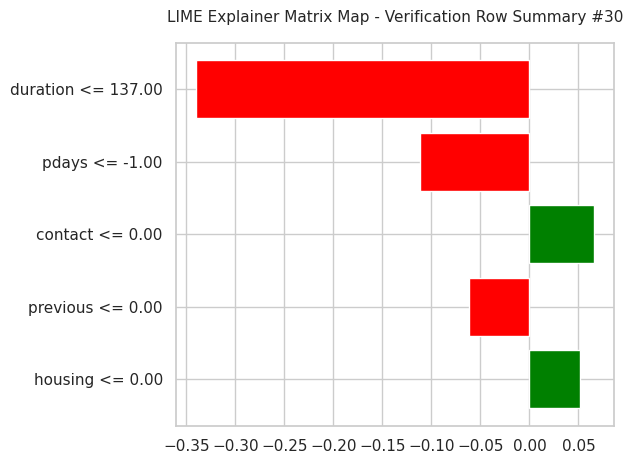


 EXPLAINING CLIENT PROFILE RECORD 4/5 (Test Row Index: 45)
Ground Truth Real Label Class: 1
Model Predicted Probability Scores: [0.32522991 0.67477009]

Local Feature Weight Influence Summary:
   -> duration > 492.00                   : Local Coefficient Weight = +0.3830
   -> pdays <= -1.00                      : Local Coefficient Weight = -0.1220
   -> contact <= 0.00                     : Local Coefficient Weight = +0.0713
   -> previous <= 0.00                    : Local Coefficient Weight = -0.0660
   -> housing <= 0.00                     : Local Coefficient Weight = +0.0431


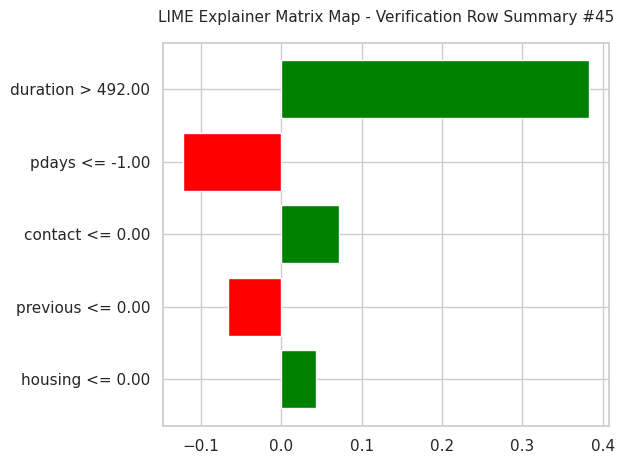


 EXPLAINING CLIENT PROFILE RECORD 5/5 (Test Row Index: 60)
Ground Truth Real Label Class: 0
Model Predicted Probability Scores: [0.92823348 0.07176652]

Local Feature Weight Influence Summary:
   -> pdays > 38.00                       : Local Coefficient Weight = +0.1142
   -> 137.00 < duration <= 253.00         : Local Coefficient Weight = -0.0937
   -> contact <= 0.00                     : Local Coefficient Weight = +0.0685
   -> 0.00 < housing <= 1.00              : Local Coefficient Weight = -0.0616
   -> balance <= 122.00                   : Local Coefficient Weight = -0.0571


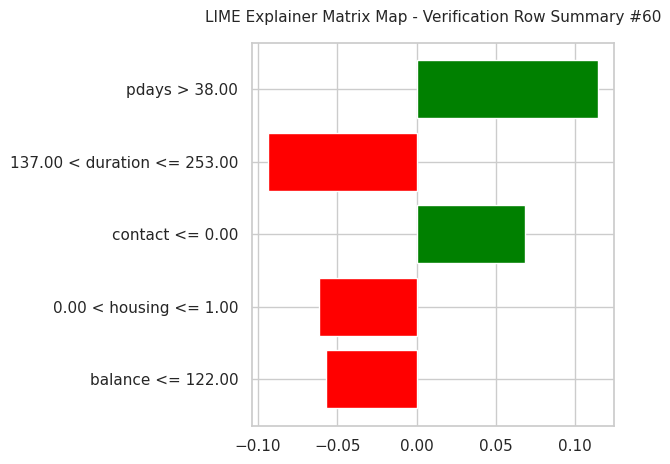

In [10]:
# ==============================================================================
# PART 6: MODEL INTERPRETABILITY (EXPLAINABLE AI - SHAP & LIME INTEGRATION)
# ==============================================================================
print("\n--- Running Global Explainable AI Frameworks (SHAP) ---")

# Convert test dataset explicitly into a DataFrame structure to ensure perfect visual graph labels
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Initialize the TreeExplainer wrapper around our Random Forest model
explainer_shap = shap.TreeExplainer(rf_clf)
shap_values = explainer_shap.shap_values(X_test_df)

# Handle differing data array formats across structural SHAP versions cleanly
if isinstance(shap_values, list):
    shap_val_target = shap_values[1] # Isolate class 1 ("Subscription Success")
else:
    shap_val_target = shap_values

# Render and Export SHAP Global Feature Importance Bar Graph
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_val_target, X_test_df, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance Analysis Chart", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=300)
plt.show()

# Render and Export SHAP Beeswarm Distribution Map
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_val_target, X_test_df, show=False)
plt.title("SHAP Beeswarm Value Variance Distribution Plot", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('shap_beeswarm_plot.png', dpi=300)
plt.show()


print("\n--- Running Local Explainer Framework (LIME) for 5 Distinct Predictions ---")

# Set up the LIME Tabular Explainer environment
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns.tolist(),
    class_names=['No Deposit Subscription', 'Subscribed Deposit Account'],
    mode='classification',
    random_state=42
)

# Select 5 distinct row indexes from across the verification partition array
target_test_indices = [0, 15, 30, 45, 60]

for iteration, test_idx in enumerate(target_test_indices):
    print(f"\n" + "="*80)
    print(f" EXPLAINING CLIENT PROFILE RECORD {iteration+1}/5 (Test Row Index: {test_idx})")
    print("="*80)

    # Calculate local linear weight distributions
    exp = explainer_lime.explain_instance(
        data_row=X_test.iloc[test_idx],
        predict_fn=rf_clf.predict_proba,
        num_features=5
    )

    # Output Ground Truth and Class Probability Estimates directly to standard log console
    print(f"Ground Truth Real Label Class: {y_test.iloc[test_idx]}")
    print(f"Model Predicted Probability Scores: {rf_clf.predict_proba(X_test.iloc[[test_idx]])[0]}")
    print("\nLocal Feature Weight Influence Summary:")
    for feature_desc, weight in exp.as_list():
        print(f"   -> {feature_desc:<35} : Local Coefficient Weight = {weight:+.4f}")

    # Render and export localized horizontal evaluation charts
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Explainer Matrix Map - Verification Row Summary #{test_idx}", fontsize=11, pad=15)
    plt.tight_layout()
    plt.savefig(f'lime_explanation_instance_{test_idx}.png', dpi=300)
    plt.show()
    plt.close()

print("\n======================================================================")
